In [24]:
import numpy as np, pandas as pd, warnings, matplotlib.pyplot as plt, seaborn as sns 
warnings.filterwarnings('ignore')
data = pd.read_csv('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Cancer.csv')
data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
data.replace({'diagnosis':{'M':1, 'B':0}}, inplace=True)

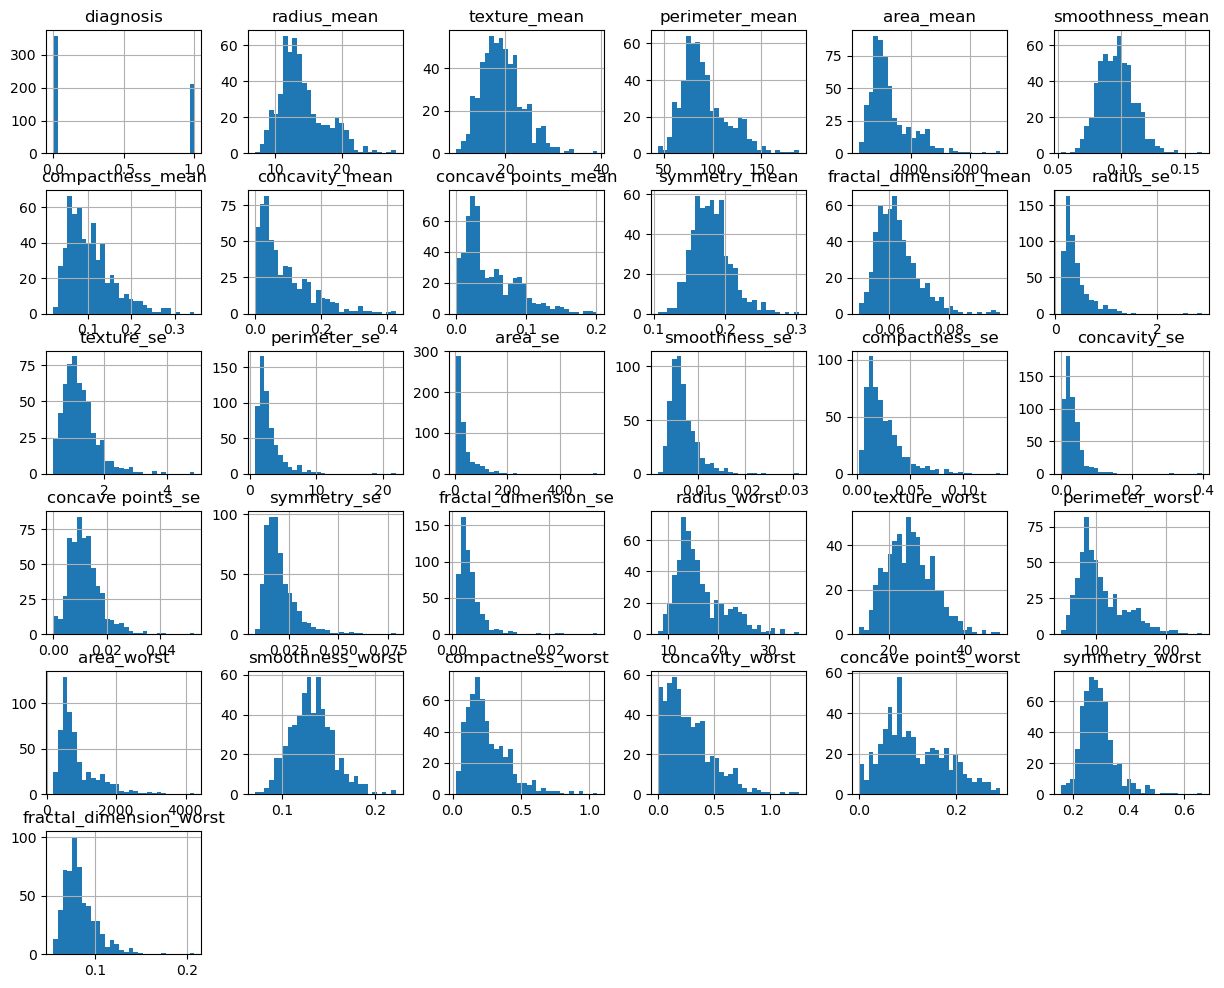

In [25]:
data.hist(figsize=(15,12), bins=30)
plt.title('Feature distributions', fontsize = 14)
plt.show()

In [26]:
# %pip install ydata-synthetic


In [27]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0/1

# Example: declare column types
# For Wisconsin, everything is numeric; 'target' is technically categorical (binary)
continuous_columns = [c for c in df.columns if c != 'target']
categorical_columns = ['target']

In [29]:
from ydata_synthetic.synthesizers.regular import RegularSynthesizer
from ydata_synthetic.synthesizers import ModelTypes

# Choose CTGAN (close to CTAB-GAN for many use cases)
model = RegularSynthesizer(modelname=ModelTypes.CTGAN)

train_args = {
    "batch_size": 256,
    "epochs": 300,          # can go higher if you like
    "learning_rate": 2e-4
}

model.train(
    data=df,
    train_arguments=train_args,
    categorical_columns=categorical_columns
)

ImportError: cannot import name 'config' from 'tensorflow' (unknown location)